## EDA

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [20]:
df = pd.read_csv('train.csv')

In [21]:
print("Dataset shape:", df.shape)

Dataset shape: (593994, 13)


In [22]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [23]:
print(df.info())
display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,593994.0,NaN,NaN,NaN,296996.5,171471.442235,0.0,148498.25,296996.5,445494.75,593993.0
annual_income,593994.0,NaN,NaN,NaN,48212.202976,26711.942078,6002.43,27934.4,46557.68,60981.32,393381.74
debt_to_income_ratio,593994.0,NaN,NaN,NaN,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,NaN,NaN,NaN,680.916009,55.424956,395.0,646.0,682.0,719.0,849.0
loan_amount,593994.0,NaN,NaN,NaN,15020.297629,6926.530568,500.09,10279.62,15000.22,18858.58,48959.95
interest_rate,593994.0,NaN,NaN,NaN,12.356345,2.008959,3.2,10.99,12.37,13.68,20.99
gender,593994,3,Female,306175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,593994,4,Single,288843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,593994,5,Bachelor's,279606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,593994,5,Employed,450645,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
target = 'loan_paid_back'
print('Target value counts:')
print(df[target].value_counts())
print('Target proportions:')
print(df[target].value_counts(normalize=True))

Target value counts:
loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64
Target proportions:
loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64


### Chart

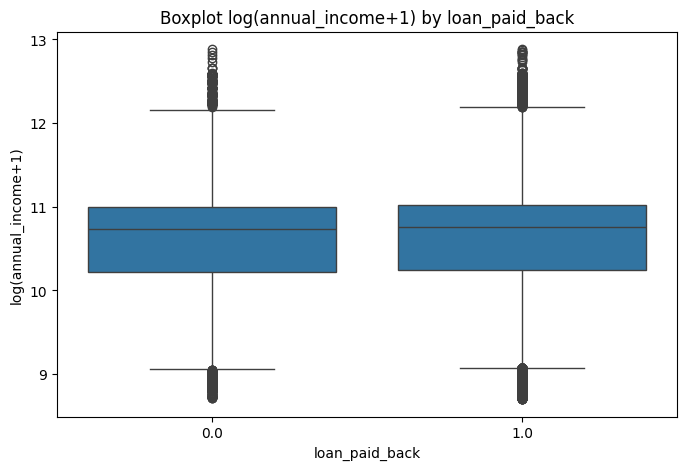

In [25]:
# Boxplot annual_income by loan_paid_back
plt.figure(figsize=(8,5))
sns.boxplot(x=df[target], y=np.log1p(df['annual_income']))
plt.title('Boxplot log(annual_income+1) by loan_paid_back')
plt.xlabel('loan_paid_back')
plt.ylabel('log(annual_income+1)')
plt.show()

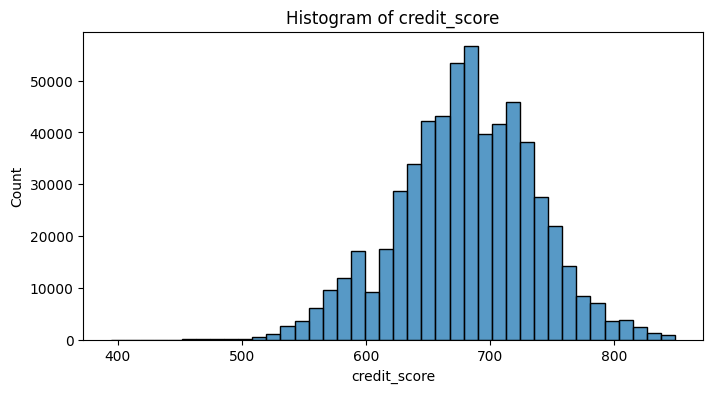

In [26]:
# Histogram credit_score
plt.figure(figsize=(8,4))
sns.histplot(df['credit_score'].dropna(), bins=40, kde=False)
plt.title('Histogram of credit_score')
plt.xlabel('credit_score')
plt.show()

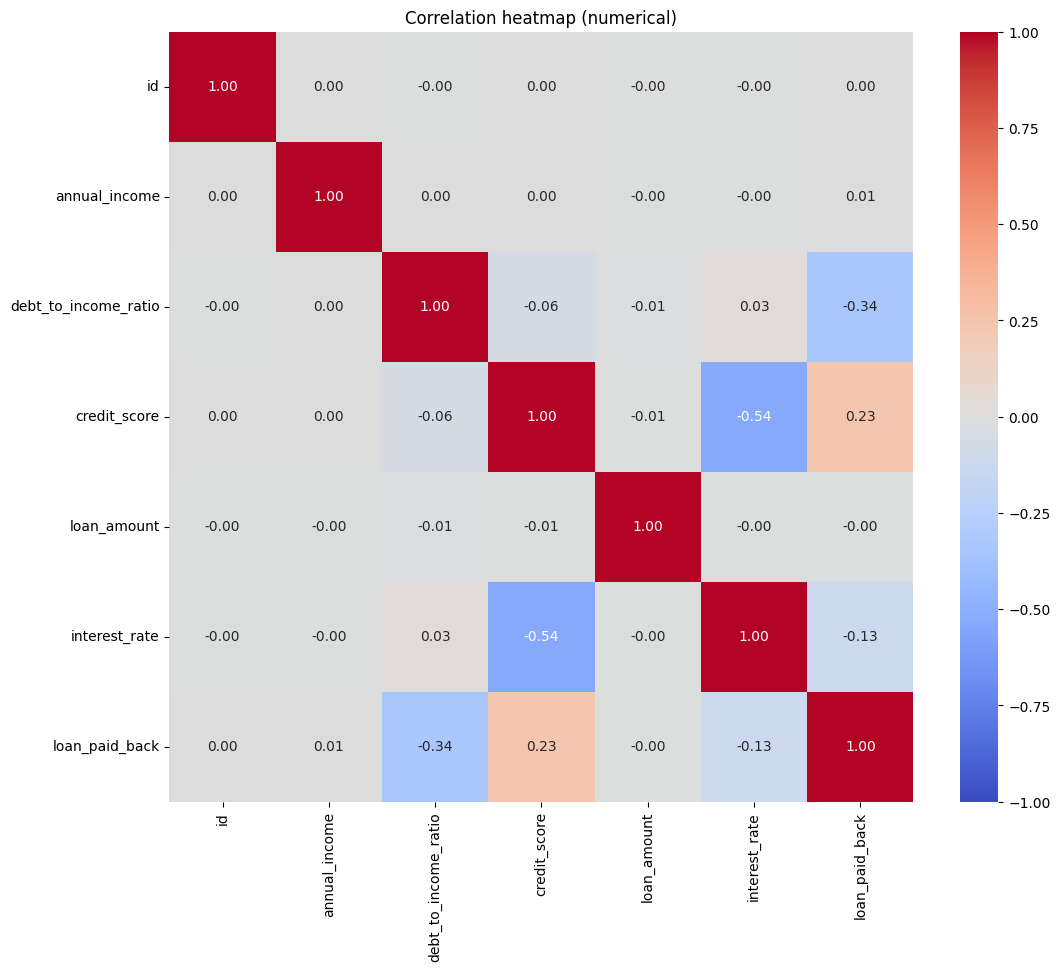

In [27]:
# 3.5 Heatmap correlation
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12,10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap (numerical)')
plt.show()

## 2. Feature Engineering

In [36]:
df_fe = df.copy()

In [37]:
# loan_to_income_ratio
if 'loan_amount' in df_fe.columns and 'annual_income' in df_fe.columns:
    df_fe['loan_to_income_ratio'] = df_fe['loan_amount'] / (df_fe['annual_income'].replace(0, np.nan).fillna(0) + 1)
else:
    df_fe['loan_to_income_ratio'] = np.nan

In [38]:
# interest_burden
if 'interest_rate' in df_fe.columns and 'loan_amount' in df_fe.columns:
    # assume interest_rate in percent (e.g., 7.5)
    df_fe['interest_burden'] = df_fe['interest_rate'].astype(float).fillna(0) * df_fe['loan_amount'].astype(float).fillna(0) / 100.0
else:
    df_fe['interest_burden'] = np.nan

In [39]:
# debt_to_income_ratio
if 'debt_to_income_ratio' in df_fe.columns:
    df_fe['debt_to_income_ratio'] = pd.to_numeric(df_fe['debt_to_income_ratio'], errors='coerce')
    df_fe['debt_risk_level'] = pd.cut(df_fe['debt_to_income_ratio'].fillna(-1),
                                       bins=[-2,0.2,0.35,0.5,1,10],
                                       labels=['very_low','low','medium','high','very_high']).astype(str)
else:
    df_fe['debt_risk_level'] = 'Missing'
    df_fe['debt_to_income_ratio'] = np.nan

In [40]:
# credit_score segments
if 'credit_score' in df_fe.columns:
    df_fe['credit_score'] = pd.to_numeric(df_fe['credit_score'], errors='coerce')
    df_fe['credit_segment'] = pd.cut(df_fe['credit_score'].fillna(-1),
                                     bins=[-2,579,669,739,799,850,1000],
                                     labels=['very_poor','fair','good','very_good','excellent','super']).astype(str)
else:
    df_fe['credit_segment'] = 'Missing'

In [41]:
# grade_tier & grade_numeric
if 'grade_subgrade' in df_fe.columns:
    # e.g., 'A1','B3' -> tier 'A' and subgrade numeric 1
    df_fe['grade_subgrade'] = df_fe['grade_subgrade'].astype(str)
    df_fe['grade_tier'] = df_fe['grade_subgrade'].str[0].fillna('Missing')
    # extract numeric part if present
    df_fe['grade_sub_numeric'] = df_fe['grade_subgrade'].str.extract('(\d+)').astype(float).fillna(-1)
else:
    df_fe['grade_tier'] = 'Missing'
    df_fe['grade_sub_numeric'] = -1

In [42]:
# interaction feature credit * loan_ratio
if 'credit_score' in df_fe.columns and 'loan_to_income_ratio' in df_fe.columns:
    df_fe['credit_x_loanratio'] = df_fe['credit_score'].fillna(df_fe['credit_score'].median()) * df_fe['loan_to_income_ratio'].fillna(0)
else:
    df_fe['credit_x_loanratio'] = np.nan

In [43]:
# is_high_income
if 'annual_income' in df_fe.columns:
    p75 = df_fe['annual_income'].quantile(0.75)
    df_fe['is_high_income'] = (df_fe['annual_income'].fillna(0) > p75).astype(int)
else:
    df_fe['is_high_income'] = 0

In [44]:
# age_bins (bucket) & is_senior flag
if 'age' in df_fe.columns:
    df_fe['age'] = pd.to_numeric(df_fe['age'], errors='coerce')
    df_fe['age_bins'] = pd.cut(df_fe['age'].fillna(-1), bins=[-2,24,34,49,64,200], labels=['<25','25-34','35-49','50-64','65+']).astype(str)
    df_fe['is_senior'] = (df_fe['age'] >= 65).astype(int).fillna(0)
else:
    df_fe['age_bins'] = 'Missing'
    df_fe['is_senior'] = 0

In [45]:
# employment tenure bucket
if 'employment_length' in df_fe.columns:
    # try numeric then bucket
    df_fe['employment_length'] = pd.to_numeric(df_fe['employment_length'], errors='coerce')
    df_fe['emp_tenure_bucket'] = pd.cut(df_fe['employment_length'].fillna(-1), bins=[-2,0,1,3,5,10,100],
                                        labels=['unemployed','0-1','1-3','3-5','5-10','10+']).astype(str)
else:
    df_fe['emp_tenure_bucket'] = 'Missing'

In [46]:
# previous defaults / negative indicator
if 'prev_default_count' in df_fe.columns:
    df_fe['has_prev_default'] = (pd.to_numeric(df_fe['prev_default_count'], errors='coerce').fillna(0) > 0).astype(int)
else:
    # sometimes we have a boolean or flag named 'defaulted_before'
    if 'defaulted_before' in df_fe.columns:
        df_fe['has_prev_default'] = df_fe['defaulted_before'].map({True:1, False:0}).fillna(0).astype(int)
    else:
        df_fe['has_prev_default'] = 0

In [47]:
created = ['loan_to_income_ratio','interest_burden','debt_to_income_ratio','debt_risk_level',
           'credit_segment','grade_tier','grade_sub_numeric','credit_x_loanratio',
           'is_high_income','age_bins','is_senior','emp_tenure_bucket','has_prev_default',
           'monthly_payment_est','loan_age_days']

created_exist = [c for c in created if c in df_fe.columns]
print('Created features (existing):', created_exist)
df_fe[created_exist].head(8)

Created features (existing): ['loan_to_income_ratio', 'interest_burden', 'debt_to_income_ratio', 'debt_risk_level', 'credit_segment', 'grade_tier', 'grade_sub_numeric', 'credit_x_loanratio', 'is_high_income', 'age_bins', 'is_senior', 'emp_tenure_bucket', 'has_prev_default']


,loan_to_income_ratio,interest_burden,debt_to_income_ratio,debt_risk_level,credit_segment,grade_tier,grade_sub_numeric,credit_x_loanratio,is_high_income,age_bins,is_senior,emp_tenure_bucket,has_prev_default
0,0.086091,345.635014,0.084,very_low,good,C,3.0,63.363334,0,Missing,0,Missing,0
1,0.207748,593.428520,0.166,very_low,fair,D,3.0,132.127593,0,Missing,0,Missing,0
2,0.343073,1659.702640,0.097,very_low,good,C,5.0,238.092410,0,Missing,0,Missing,0
3,0.099926,753.879280,0.065,very_low,very_poor,F,1.0,53.260815,0,Missing,0,Missing,0
4,0.477864,1244.030303,0.053,very_low,fair,D,1.0,317.779484,0,Missing,0,Missing,0
5,0.270573,1488.374208,0.058,very_low,fair,D,1.0,176.684425,0,Missing,0,Missing,0
6,0.274587,2285.922392,0.042,very_low,good,C,5.0,191.112230,1,Missing,0,Missing,0
7,0.220036,1296.309684,0.100,very_low,fair,D,1.0,143.903792,0,Missing,0,Missing,0


## 3. Preprocessing

In [48]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

In [49]:
# Raw numeric
num_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()

In [51]:
# Numeric FE
num_fe = [
    'loan_to_income_ratio',
    'interest_burden',
    'credit_x_loanratio',
    'grade_sub_numeric',
    'loan_age_days',
    'monthly_payment_est'
]

In [52]:
# Numeric in total
num_cols_model = [c for c in num_cols_raw + num_fe if c in df_fe.columns]

In [53]:
# Categorical
cat_required = [
    'gender',
    'marital_status',
    'education',
    'employment_status',
    'loan_purpose',
    'grade_subgrade'
]

In [54]:
# Categorical from FE
cat_fe = [
    'debt_risk_level',
    'credit_segment',
    'grade_tier',
    'age_bins',
    'emp_tenure_bucket'
]

In [55]:
cat_cols_model = [c for c in cat_required + cat_fe if c in df_fe.columns]

print("Numeric cols used:", len(num_cols_model))
print(num_cols_model)
print("Categorical cols used:", len(cat_cols_model))
print(cat_cols_model)

Numeric cols used: 11
['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_paid_back', 'loan_to_income_ratio', 'interest_burden', 'credit_x_loanratio', 'grade_sub_numeric']
Categorical cols used: 10
['gender', 'marital_status', 'employment_status', 'loan_purpose', 'grade_subgrade', 'debt_risk_level', 'credit_segment', 'grade_tier', 'age_bins', 'emp_tenure_bucket']


In [57]:
# Numeric pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols_model),
        ('cat', cat_pipeline, cat_cols_model)
    ],
    remainder='drop'
)

### 4. PySpark

In [59]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("loan_analysis_pyspark") \
    .master("local[*]") \
    .config("spark.driver.memory","6g") \
    .getOrCreate()


In [60]:
from pyspark.sql import functions as F

DATA_PATH = 'train.csv'

spark_df = spark.read.option("header", True).option("inferSchema", True).csv(DATA_PATH)
print("Rows (spark):", spark_df.count())
spark_df.printSchema()
spark_df.show(5, truncate=False)

Rows (spark): 593994
root
 |-- id: integer (nullable = true)
 |-- annual_income: double (nullable = true)
 |-- debt_to_income_ratio: double (nullable = true)
 |-- credit_score: integer (nullable = true)
 |-- loan_amount: double (nullable = true)
 |-- interest_rate: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- education_level: string (nullable = true)
 |-- employment_status: string (nullable = true)
 |-- loan_purpose: string (nullable = true)
 |-- grade_subgrade: string (nullable = true)
 |-- loan_paid_back: double (nullable = true)

+---+-------------+--------------------+------------+-----------+-------------+------+--------------+---------------+-----------------+------------------+--------------+--------------+
|id |annual_income|debt_to_income_ratio|credit_score|loan_amount|interest_rate|gender|marital_status|education_level|employment_status|loan_purpose      |grade_subgrade|loan_paid_back|
+---+-------------+---

In [61]:
cols_to_cast = ['loan_paid_back', 'credit_score', 'loan_amount', 'annual_income', 'debt_to_income_ratio', 'interest_rate']

for c in cols_to_cast:
    if c in spark_df.columns:
        spark_df = spark_df.withColumn(c, F.col(c).cast('double'))

# Check for the short schema
spark_df.select([c for c in cols_to_cast if c in spark_df.columns]).printSchema()

root
 |-- loan_paid_back: double (nullable = true)
 |-- credit_score: double (nullable = true)
 |-- loan_amount: double (nullable = true)
 |-- annual_income: double (nullable = true)
 |-- debt_to_income_ratio: double (nullable = true)
 |-- interest_rate: double (nullable = true)



In [62]:
# Determine the education column name (education_level or education)
if 'education_level' in spark_df.columns:
    edu_col = 'education_level'
elif 'education' in spark_df.columns:
    edu_col = 'education'
else:
    edu_col = None

In [63]:
# Target column
target_col = 'loan_paid_back'

if edu_col is None:
    print("Column 'education_level' or 'education' was not found in the Spark dataset.")
else:
    if target_col not in spark_df.columns:
        print(f"Target column '{target_col}' was not found in the Spark DataFrame.")
    else:
        # Aggregate: group by education -> count, sum(paid back), mean(paid back)
        agg_edu = spark_df.groupBy(edu_col) \
            .agg(
                F.count('*').alias('n'),
                F.sum(F.col(target_col).cast('double')).alias('n_paid_back'),
                F.mean(F.col(target_col).cast('double')).alias('avg_paid_back')
            ) \
            .orderBy(F.desc('avg_paid_back'))

        # Show the result in Spark
        agg_edu.show(200, truncate=False)

        # Export aggregated result to pandas (use toPandas() only if result is small)
        agg_edu_pdf = agg_edu.toPandas()
        print("agg_edu_pdf shape:", agg_edu_pdf.shape)
        display(agg_edu_pdf)

+---------------+------+-----------+------------------+
|education_level|n     |n_paid_back|avg_paid_back     |
+---------------+------+-----------+------------------+
|PhD            |11022 |9149.0     |0.8300671384503719|
|High School    |183592|148654.0   |0.809697590308946 |
|Other          |26677 |21416.0    |0.8027889192937737|
|Master's       |93097 |74696.0    |0.8023459402558621|
|Bachelor's     |279606|220579.0   |0.7888922269193079|
+---------------+------+-----------+------------------+

agg_edu_pdf shape: (5, 4)


,education_level,n,n_paid_back,avg_paid_back
0,PhD,11022,9149.0,0.830067
1,High School,183592,148654.0,0.809698
2,Other,26677,21416.0,0.802789
3,Master's,93097,74696.0,0.802346
4,Bachelor's,279606,220579.0,0.788892


In [64]:
# Bucket credit_score into ranges and aggregate
if 'credit_score' not in spark_df.columns:
    print("Column 'credit_score' not found in Spark DataFrame. Skipping credit bucketing.")
else:
    spark_df_bkt = spark_df.withColumn(
        'credit_bucket',
        F.when(F.col('credit_score') < 580, 'very_low')
         .when(F.col('credit_score') < 670, 'low')
         .when(F.col('credit_score') < 740, 'medium')
         .when(F.col('credit_score') < 800, 'high')
         .otherwise('very_high')
    )

    # Aggregation: count, paid-back rate, median credit score per bucket
    agg_credit = spark_df_bkt.groupBy('credit_bucket') \
        .agg(
            F.count('*').alias('n'),
            F.mean(F.col(target_col).cast('double')).alias('paid_back_rate'),
            F.expr('percentile_approx(credit_score, 0.5)').alias('median_credit_score')
        ) \
        .orderBy('credit_bucket')

    # Show aggregated results
    agg_credit.show(truncate=False)

    # Export the aggregated result to pandas
    agg_credit_pdf = agg_credit.toPandas()
    print("agg_credit_pdf shape:", agg_credit_pdf.shape)
    display(agg_credit_pdf)

+-------------+------+------------------+-------------------+
|credit_bucket|n     |paid_back_rate    |median_credit_score|
+-------------+------+------------------+-------------------+
|high         |71337 |0.931970786548355 |756.0              |
|low          |209954|0.7053687950693962|641.0              |
|medium       |275585|0.8472485802928316|699.0              |
|very_high    |9852  |0.9522939504669102|813.0              |
|very_low     |27266 |0.6251008582116923|565.0              |
+-------------+------+------------------+-------------------+

agg_credit_pdf shape: (5, 4)


,credit_bucket,n,paid_back_rate,median_credit_score
0,high,71337,0.931971,756.0
1,low,209954,0.705369,641.0
2,medium,275585,0.847249,699.0
3,very_high,9852,0.952294,813.0
4,very_low,27266,0.625101,565.0


In [65]:
# Export Spark
N = 200_000

try:
    if N is None:
        spark_pdf = spark_df.toPandas()
    else:
        spark_pdf = spark_df.limit(N).toPandas()
    print("Converted Spark -> pandas. spark_pdf shape:", spark_pdf.shape)
    display(spark_pdf.head(5))
except Exception as e:
    print("Failed to convert Spark DataFrame to pandas (likely memory issue):", e)
    print("Consider using a smaller limit or writing parquet and reading in chunks.")


Converted Spark -> pandas. spark_pdf shape: (200000, 13)


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736.0,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636.0,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694.0,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533.0,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665.0,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


## 5. Modeling

In [66]:
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, precision_recall_curve
import xgboost as xgb

In [68]:
# Define target
target = 'loan_paid_back'
if target not in spark_pdf.columns:
    raise RuntimeError(f"Target column '{target}' not found in spark_pdf. Please check column names: {spark_pdf.columns.tolist()[:30]}")

# Convert boolean or string labels to 0/1
if spark_pdf[target].dtype == 'bool':
    spark_pdf[target] = spark_pdf[target].astype(int)
elif spark_pdf[target].dtype == object:
    # attempt mapping common string labels
    uniques = spark_pdf[target].dropna().unique().tolist()
    if set(uniques) <= set(['yes','no','Yes','No','Y','N','1','0']):
        spark_pdf[target] = spark_pdf[target].map(lambda x: 1 if str(x).lower() in ['yes','y','1','true','t'] else 0)
    else:
        try:
            spark_pdf[target] = pd.to_numeric(spark_pdf[target])
        except:
            raise RuntimeError(f"Target column '{target}' seems non-numeric and cannot be auto-converted. Unique values: {uniques[:10]}")

In [69]:
# Indentify numeric and categorical columns
num_cols_raw = spark_pdf.select_dtypes(include=[np.number]).columns.tolist()
if target in num_cols_raw:
    num_cols_raw.remove(target)

In [70]:
# engineered numeric features
engineered_num = [c for c in ['loan_to_income_ratio','monthly_payment_est','grade_sub_numeric','credit_x_loanratio','loan_age_days'] if c in spark_pdf.columns]
num_cols_model = [c for c in num_cols_raw if c not in engineered_num] + engineered_num
num_cols_model = [c for c in num_cols_model if c in spark_pdf.columns]

In [71]:
# categorical columns required by the assignment + FE categorical
cat_required = [c for c in ['gender','marital_status','education','employment_status','loan_purpose','grade_subgrade'] if c in spark_pdf.columns]
cat_fe = [c for c in ['grade_tier','debt_risk_level','credit_segment','age_bins','emp_tenure_bucket'] if c in spark_pdf.columns]
cat_cols_model = cat_required + cat_fe

In [72]:
print("Numeric features used (count):", len(num_cols_model))
print(num_cols_model)
print("Categorical features used (count):", len(cat_cols_model))
print(cat_cols_model)

Numeric features used (count): 6
['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
Categorical features used (count): 5
['gender', 'marital_status', 'employment_status', 'loan_purpose', 'grade_subgrade']


In [73]:
# Preprocessing Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

In [74]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols_model),
        ('cat', cat_pipeline, cat_cols_model)
    ],
    remainder='drop',
    sparse_threshold=0
)

In [75]:
# Prepare X, y and split
X = spark_pdf[num_cols_model + cat_cols_model].copy()
y = spark_pdf[target].astype(int).copy()

# avoid all-null numeric columns
for c in num_cols_model:
    if X[c].isna().all():
        X[c] = 0
        print(f"Warning: numeric column {c} was all null -> filled with zeros for modeling.")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [76]:
# Fit transformer on training set
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("Preprocessing done. X_train shape:", X_train.shape, "X_test shape:", X_test.shape)

Preprocessing done. X_train shape: (160000, 56) X_test shape: (40000, 56)


In [77]:
# Extract feature names
ohe_obj = preprocessor.named_transformers_['cat'].named_steps['ohe']
try:
    ohe_feature_names = ohe_obj.get_feature_names_out(cat_cols_model).tolist()
except Exception:
    # fallback name generation
    ohe_feature_names = []
    for c in cat_cols_model:
        vals = X_train_raw[c].dropna().unique().tolist()[:30]
        ohe_feature_names += [f"{c}__{v}" for v in vals]

feature_names = num_cols_model + ohe_feature_names
print("Total features after preprocessing:", len(feature_names))

Total features after preprocessing: 56


### Logistic Regression

In [78]:
lr = LogisticRegression(max_iter=2000, class_weight='balanced')
lr.fit(X_train, y_train)
proba_lr = lr.predict_proba(X_test)[:,1]

### XGBoost

In [79]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test, label=y_test)
params = {'objective':'binary:logistic','eval_metric':'auc','verbosity':0}
bst = xgb.train(params, dtrain, num_boost_round=300)
proba_xgb = bst.predict(dtest)

### Metrics

In [80]:
def precision_at_k(y_true, y_scores, k):
    n = len(y_scores)
    top_n = max(int(np.floor(k * n)), 1)
    idx = np.argsort(y_scores)[-top_n:]
    return y_true.iloc[idx].sum() / top_n

def best_threshold_by_f1(y_true, y_scores):
    prec, rec, thr = precision_recall_curve(y_true, y_scores)
    f1s = 2*prec*rec/(prec+rec+1e-12)
    best_idx = np.nanargmax(f1s)
    best_thr = thr[best_idx] if best_idx < len(thr) else 0.5
    return best_thr, f1s[best_idx]

In [81]:
# Logistic Regression metrics
auc_lr = roc_auc_score(y_test, proba_lr)
f1_lr = f1_score(y_test, (proba_lr >= 0.5).astype(int))
p20_lr = precision_at_k(y_test.reset_index(drop=True), pd.Series(proba_lr), 0.2)
p10_lr = precision_at_k(y_test.reset_index(drop=True), pd.Series(proba_lr), 0.1)
cm_lr = confusion_matrix(y_test, (proba_lr >= 0.5).astype(int))
thr_lr, bestf1_lr = best_threshold_by_f1(y_test, proba_lr)


In [82]:
# XGBoost metrics
auc_xgb = roc_auc_score(y_test, proba_xgb)
f1_xgb = f1_score(y_test, (proba_xgb >= 0.5).astype(int))
p20_xgb = precision_at_k(y_test.reset_index(drop=True), pd.Series(proba_xgb), 0.2)
p10_xgb = precision_at_k(y_test.reset_index(drop=True), pd.Series(proba_xgb), 0.1)
cm_xgb = confusion_matrix(y_test, (proba_xgb >= 0.5).astype(int))
thr_xgb, bestf1_xgb = best_threshold_by_f1(y_test, proba_xgb)

In [83]:
# Print evaluation results
print("\n=== Logistic Regression ===")
print(f"ROC-AUC: {auc_lr:.4f}")
print(f"F1 (threshold=0.5): {f1_lr:.4f}")
print(f"Precision@20%: {p20_lr:.4f}")
print(f"Precision@10%: {p10_lr:.4f}")
print("Confusion matrix (threshold=0.5):")
print(cm_lr)
print(f"Best threshold by F1: {thr_lr:.4f} (F1={bestf1_lr:.4f})")

print("\n=== XGBoost ===")
print(f"ROC-AUC: {auc_xgb:.4f}")
print(f"F1 (threshold=0.5): {f1_xgb:.4f}")
print(f"Precision@20%: {p20_xgb:.4f}")
print(f"Precision@10%: {p10_xgb:.4f}")
print("Confusion matrix (threshold=0.5):")
print(cm_xgb)
print(f"Best threshold by F1: {thr_xgb:.4f} (F1={bestf1_xgb:.4f})")


=== Logistic Regression ===
ROC-AUC: 0.9129
F1 (threshold=0.5): 0.9119
Precision@20%: 0.9910
Precision@10%: 0.9932
Confusion matrix (threshold=0.5):
[[ 6256  1828]
 [ 3635 28281]]
Best threshold by F1: 0.1301 (F1=0.9417)

=== XGBoost ===
ROC-AUC: 0.9144
F1 (threshold=0.5): 0.9402
Precision@20%: 0.9912
Precision@10%: 0.9938
Confusion matrix (threshold=0.5):
[[ 4984  3100]
 [  851 31065]]
Best threshold by F1: 0.4025 (F1=0.9416)


In [84]:
try:
    importance_dict = bst.get_score(importance_type='gain')  # feature -> importance
    # bst features are named 'f0','f1',... so map to feature_names
    imp_list = [(int(k[1:]), v) for k,v in importance_dict.items() if k.startswith('f')]
    imp_list_sorted = sorted(imp_list, key=lambda x: x[1], reverse=True)[:20]
    print("\nTop XGBoost feature importances (gain):")
    for idx, score in imp_list_sorted:
        fname = feature_names[idx] if idx < len(feature_names) else f"f{idx}"
        print(f"{fname:40s} : {score:.4f}")
except Exception as e:
    print("Could not extract XGBoost importances or map to names:", e)


Top XGBoost feature importances (gain):
employment_status_Unemployed             : 1029.6526
employment_status_Student                : 130.6317
employment_status_Retired                : 41.5496
debt_to_income_ratio                     : 16.1390
credit_score                             : 10.9294
grade_subgrade_F3                        : 4.0624
employment_status_Self-employed          : 3.8664
grade_subgrade_D1                        : 3.6995
grade_subgrade_D3                        : 3.6922
loan_purpose_Education                   : 3.6162
grade_subgrade_C2                        : 3.6124
loan_purpose_Home                        : 3.5743
marital_status_Divorced                  : 3.5641
grade_subgrade_D4                        : 3.5410
loan_purpose_Other                       : 3.5405
loan_purpose_Medical                     : 3.4909
loan_purpose_Business                    : 3.4895
grade_subgrade_E4                        : 3.4660
grade_subgrade_D2                        : 3.4635
l